# Example Code for SSD A017

## Step 1: Import packages for use in Python code and define some functions to use

In [48]:
#Programes and functions
import pandas as pd
import numpy as np
np.float = float 
np.int = int
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import datetime
import sklearn
import linecache2 as linecache
import regex as re
import scipy.stats as stats

from matplotlib import pyplot as plt 
from scipy.io import loadmat
from scipy import interpolate
from sklearn import linear_model, datasets
from sklearn.linear_model import LinearRegression
from scipy.interpolate import UnivariateSpline
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# For eaxtracting Metadata
def extract_metadata(file):
    def extract_line(index, float_=True):
        line = linecache.getline(file, index)
        nums = re.findall(r'-?\d+\.?\d*', line)
        return np.array(nums, dtype=float) if float_ else nums
    SD = extract_line(1)
    FU = extract_line(2)
    pH = extract_line(3)
    SN = extract_line(4)
    lat = extract_line(5)
    lon = extract_line(6)
    # Fix date parsing
    date_line = linecache.getline(file, 7)
    date = re.findall(r'\d+', date_line)
    year, month, day = map(float, date[:3])
    print(f"Year = {year}\nMonth = {month}\nDay = {day}")
    print(f"Latitude = {lat[0]}° N\nLongitude = {lon[0]}° E")
    print(f"Zsd = {SD[0]} cm \nFU = {FU[0]}")
    return year, month, day, lat[0], lon[0], SD[0], FU[0]

# For extracting column name
def col(name):
    return df.loc[:, name].to_numpy()

# Convert time to seconds
def convert_time_to_sec(times):
    times_sec = []
    for t in times:
        h, m, s = map(int, t.split(':'))
        times_sec.append(h*3600 + m*60 + s)
    return np.array(times_sec)

# --- Regression Fitting Function --- Fits K in top 30 meters
def fit_k_profile(Y, X, threshold_low=0.1, threshold_high=30):
    mask = (Y > 0) & (X > threshold_low) & (X < threshold_high)
    X_fit, Y_fit = X[mask], np.log(Y[mask])
    model = LinearRegression().fit(X_fit.reshape(-1, 1), Y_fit.reshape(-1, 1))

    # Stats
    r_val = stats.pearsonr(X_fit, Y_fit)[0]
    N, p = len(X_fit), 2
    X_design = np.column_stack((np.ones(N), X_fit))
    y_hat = model.predict(X_fit.reshape(-1, 1))
    residuals = Y_fit.reshape(-1, 1) - y_hat
    sigma_sq = (residuals.T @ residuals) / (N - p)
    var_b = np.linalg.inv(X_design.T @ X_design) * sigma_sq
    se = np.sqrt(np.diag(var_b))

    intercept = model.intercept_[0]
    slope = model.coef_[0][0]

    return intercept, -slope, se[0], se[1], r_val

# --- Fit Light Profiles ---
def fit_all_profiles(data_dict, depth_array):
    G, K, G_SE, K_SE, R = [], [], [], [], []
    for wl in WAVELENGTHS:
        g, k, g_se, k_se, r = fit_k_profile(data_dict[wl], depth_array)
        G.append(g); K.append(k)
        G_SE.append(g_se); K_SE.append(k_se)
        R.append(r)
    return np.array(G), np.array(K), np.array(G_SE), np.array(K_SE), np.array(R)

# Function to plot ED and EU with fit lines
def plot_light(ax, ed_data, eu_data, depth_ed, depth_eu, fit_idx, WAVELENGTHS):
    im_ed = ax.scatter(ed_data, depth_ed, c=DATA_SEC0, marker='o', s=50, edgecolors='k', linewidth=0.2, cmap='Blues_r')
    im_eu = ax.scatter(eu_data, depth_eu, c=DATA_SEC0, marker='s', s=50, edgecolors='k', linewidth=0.2, cmap='Reds_r')
    ax.plot(np.exp(GD_spect[fit_idx]) * np.exp(-KD_spect[fit_idx] * Depth_sim), Depth_sim, '-', color='darkblue', label='ED')
    ax.plot(np.exp(GU_spect[fit_idx]) * np.exp(-KU_spect[fit_idx] * Depth_sim), Depth_sim, '--', color='darkred', label='EU')
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_xlabel(f'Light ({WAVELENGTHS}nm)', fontsize=12)
    ax.set_ylim([np.max(Depth_SS_TU)+1, 0])
    ax.set_xscale('log')
    cbar_ed = fig.colorbar(im_ed, ax=ax)
    cbar_ed.set_label("Seconds")
    cbar_ed.ax.set_title("ED")
    cbar_eu = fig.colorbar(im_eu, ax=ax)
    cbar_eu.set_label("Seconds")
    cbar_eu.ax.set_title("EU")
    ax.legend(loc="upper left", fontsize=8)

# Function for simple ED/EU scatter plots (no fit lines)
def plot_light_simple(ax, ed_data, eu_data, depth_ed, depth_eu, label):
    im_ed = ax.scatter(ed_data, depth_ed, c=DATA_SEC0, marker='o', s=50, edgecolors='k', linewidth=0.2, cmap='Blues_r')
    im_eu = ax.scatter(eu_data, depth_eu, c=DATA_SEC0, marker='s', s=50, edgecolors='k', linewidth=0.2, cmap='Reds_r')
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_xlabel(f'Light ({label})', fontsize=12)
    ax.set_ylim([np.max(Depth_SS_TU)+1, 0])
    ax.set_xscale('log')
    cbar_ed = fig.colorbar(im_ed, ax=ax)
    cbar_ed.set_label("Seconds")
    cbar_ed.ax.set_title("ED")
    cbar_eu = fig.colorbar(im_eu, ax=ax)
    cbar_eu.set_label("Seconds")
    cbar_eu.ax.set_title("EU")

# Function for Kd and Ku spectra plot
def plot_k_spectra(ax):
    ax.plot(WAVELENGTHS, KD_spect, 'b-', label='Kd', linewidth=2)
    ax.errorbar(WAVELENGTHS, KD_spect, yerr=KD_spect_SE, fmt='o', color='b', markersize=6)
    ax.plot(WAVELENGTHS, KU_spect, 'r-', label='Ku', linewidth=2)
    ax.errorbar(WAVELENGTHS, KU_spect, yerr=KU_spect_SE, fmt='s', color='r', markersize=6)
    ax.set_ylim([0, 4])
    ax.set_yticks(np.arange(0, 4.5, 0.5))
    ax.set_xlabel('Wavelength (nm)', fontsize=14)
    ax.set_ylabel('$K$ (m$^{-1}$)', fontsize=14)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_facecolor('#eaeaf2')
    ax.grid(color='white', alpha=0.75, linewidth=2)
    ax.set_axisbelow(True)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

## Step 2: Add file you want to process 

In [49]:
FILE = "/Users/diegomorales/Library/CloudStorage/OneDrive-UNC-Wilmington/SSD Repo/SSDiego/src/Jupyter_Notebook/260625-01(M18)-A017.txt"

## Step 3: Read file in, define SSD A013 wavelengths, fit beer-lambert law

In [50]:
# Wavelengths of A017
WAVELENGTHS = [415, 445, 480, 515, 555, 590, 630, 680]
LIGHT_LABELS = [f"{wl}nm" for wl in WAVELENGTHS]
 
# Extract metadata
year, month, day, lat, lon, SD, FU = extract_metadata(FILE)

# --- Load Profile Data ---
df = pd.read_csv(FILE, header=7)
Time_SS         = col('Time (UTC)')
Pressure_SS     = col(' Pressure (mbar) MS5803')
Temp_MS5803_SS  = col(' Temp (deg C) MS5803')
Temp_10KTHERM_SS= col(' Temp (deg C) 10KTHERM')
Temp_TH_SS      = col(' Temp (deg C) TMP117')

# Light data
ED = {wl: col(f' ED {wl}nm') for wl in WAVELENGTHS}
EU = {wl: col(f' EU {wl}nm') for wl in WAVELENGTHS}
ED['Clear']     = col(' ED Clear')
ED['NIR']       = col(' ED NIR')
EU['Clear']     = col(' EU Clear')
EU['NIR']       = col(' EU NIR')

# --- Time & Depth Processing ---
ATMOS_P = np.median(Pressure_SS[:5])
Depth_SS = (Pressure_SS - ATMOS_P) / 100.0
Depth_SS_TU = Depth_SS + 0.007
Depth_SS_LD = Depth_SS - 0.03
DATA_SEC = convert_time_to_sec(Time_SS)
DATA_SEC0 = DATA_SEC - DATA_SEC[0]

# Fits a Beer lambert law to the data
GD_spect, KD_spect, GD_spect_SE, KD_spect_SE, RD_spect = fit_all_profiles(ED, Depth_SS_LD)
GU_spect, KU_spect, GU_spect_SE, KU_spect_SE, RU_spect = fit_all_profiles(EU, Depth_SS_TU)

Year = 2026.0
Month = 6.0
Day = 25.0
Latitude = 33.91108° N
Longitude = -78.01556° E
Zsd = 130.0 cm 
FU = 99.0


## Step 4: Plot raw data

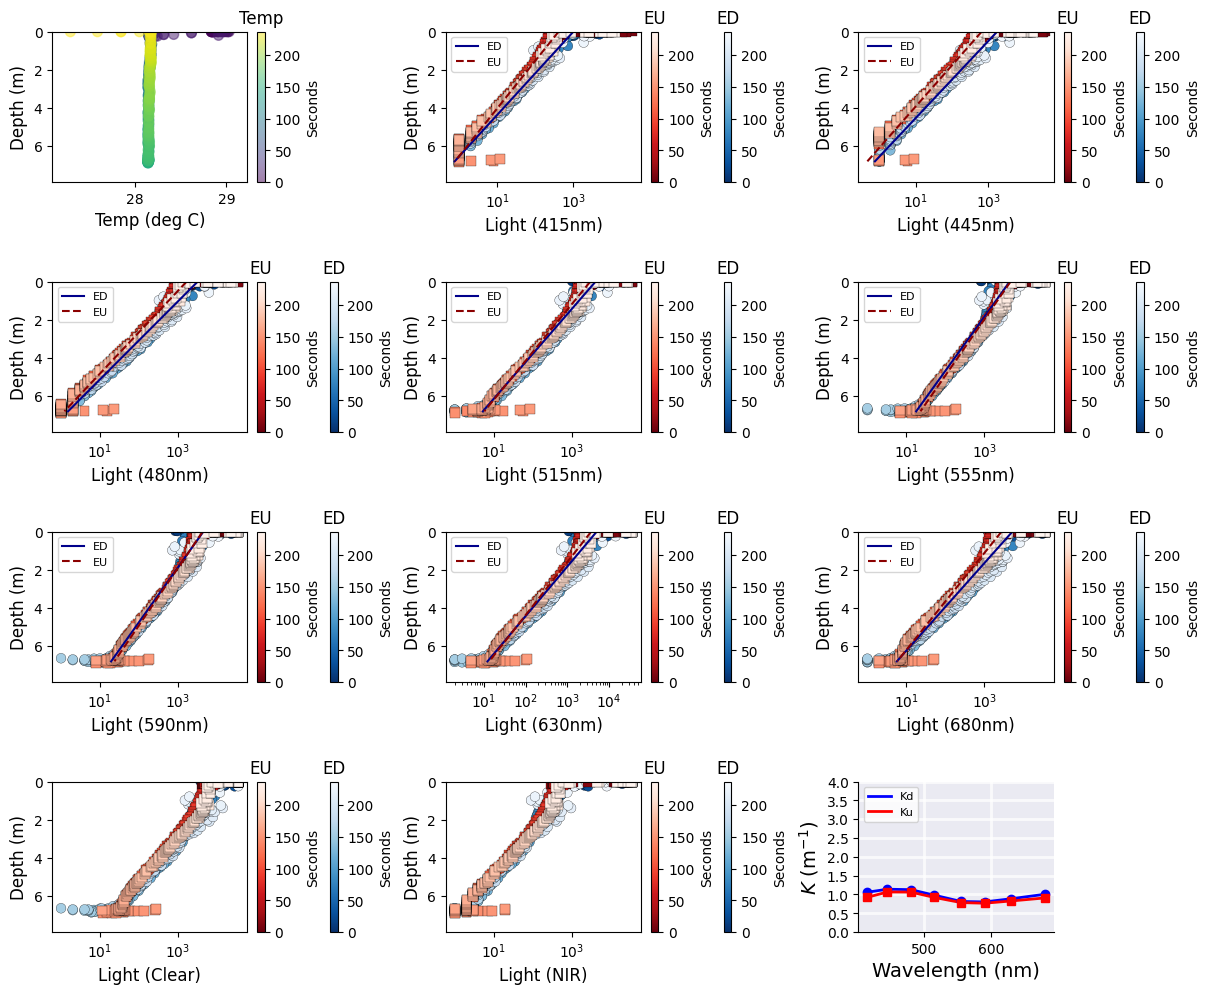

In [51]:
# Depth array for simulation
Depth_sim = np.arange(0,np.max(Depth_SS), 0.1)

# Setup figure
fig, axes = plt.subplots(4, 3, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

# Plot temperature
ax0 = axes[0]
im_temp = ax0.scatter(Temp_TH_SS, Depth_SS_TU, c=DATA_SEC0, marker='o', s=50, alpha=0.5)
ax0.set_ylabel('Depth (m)', fontsize=12)
ax0.set_xlabel('Temp (deg C)', fontsize=12)
ax0.set_ylim([np.max(Depth_SS_TU)+1, 0])
ax0.set_xlim([np.min(Temp_TH_SS)-0.2, np.max(Temp_TH_SS)+0.2])
cbar_temp = fig.colorbar(im_temp, ax=ax0)
cbar_temp.set_label("Seconds")
cbar_temp.ax.set_title("Temp")

# Plot wavelengths with simulated fits
ED_list = [ED[wl] for wl in WAVELENGTHS]
EU_list = [EU[wl] for wl in WAVELENGTHS]

for i, (ed, eu, wl) in enumerate(zip(ED_list, EU_list, WAVELENGTHS), start=1):
    plot_light(axes[i], ed, eu, Depth_SS_LD, Depth_SS_TU, i-1, wl)

# Plot clear and NIR channels (no fit lines)
plot_light_simple(axes[9], ED['Clear'], EU['Clear'], Depth_SS_LD, Depth_SS_TU, 'Clear')
plot_light_simple(axes[10], ED['NIR'], EU['NIR'],  Depth_SS_LD, Depth_SS_TU, 'NIR')

# Plot spectra
plot_k_spectra(axes[11])

plt.show()